# Mask exploration, area- and intensity-based filtering
This notebook is a fast interactive QC step used **after segmentation**.
It loads one image and its mask, computes object properties, and helps tune filtering thresholds before batch processing.

## 1. Data loading and viewer setup
The code cell below imports required libraries, selects one `.ims` image and matching mask, and loads them into memory.
It opens a Napari viewer with image and mask overlays.
Only downsampled image is loaded to speed up interactive visualization, and the mask is displayed with XY downsampling (`::4, ::4`) to match the downsampling.

In [1]:
import napari
from bioio import BioImage
import skimage
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

image = r"L:\0_Service\Sarah\Croatia project\22\22_P301S+Cykla_NeuN,AT8_27_first_2026-02-27_Tile scan_13.56.31_FusionStitcher.ims"
mask = r"L:\0_Service\Sarah\Croatia project\masks_cellpose_sam_3d_Algernon\22\22_P301S+Cykla_NeuN,AT8_27_first_2026-02-27_Tile scan_13.56.31_FusionStitcher_mask_3d.tif"

# image = r"L:\0_Service\Sarah\Croatia project\44\44_P301S+PLA_NeuN,AT8_26_third_2026-02-27_Tile scan_15.32.13_FusionStitcher.ims"
# mask = r"L:\0_Service\Sarah\Croatia project\masks_cellpose_sam_3d_Algernon\44\44_P301S+PLA_NeuN,AT8_26_third_2026-02-27_Tile scan_15.32.13_FusionStitcher_mask_3d.tif"

# Load image
img = BioImage(image)
xy_spacing = img.metadata.images[0].pixels.physical_size_x
z_spacing = img.metadata.images[0].pixels.physical_size_z

img.set_scene(scene_id=2)   # load downscaled version for faster loading
image_data = img.get_image_data("CZYX", C=1).squeeze()

# Load mask
img_mask = BioImage(mask)
img_mask.set_scene(scene_id=0)
mask_data = img_mask.get_image_data().squeeze()

# Viewer
viewer = napari.Viewer()

viewer.add_image(image_data, name="image", contrast_limits=[100,2000])
viewer.add_labels(mask_data[::1, ::4, ::4], name="mask")

<Labels layer 'mask' at 0x19821c7eaa0>

## 2. Object property computation
The code cell below computes region properties from the labeled mask (including area) and loads the per-object CSV (use if available; for looking at intensity measurements).

In [9]:
props = skimage.measure.regionprops(mask_data, spacing=(z_spacing, xy_spacing, xy_spacing))

labels = np.array([prop.label for prop in props])
areas = np.array([prop.area for prop in props])

# If properties were saved to a .csv file, load them like this:
# props_df = pd.read_csv(r"L:\0_Service\Sarah\Croatia project\histograms\22_P301S+Cykla_NeuN,AT8_27_first_2026-02-27_Tile scan_13.56.31_FusionStitcher_props.csv")

## 3. Threshold testing and class visualization
The code cell below applies candidate thresholds for size and green intensity to split labels into:
- small objects
- large objects
- dim green objects
- valid objects that pass all filters

Each subset is added to the viewer as a separate label layer for visual QC.

In [8]:
min_area = 250
max_area = 4000
min_green_intensity = 150

small_labels = labels[areas < min_area]
large_labels = labels[areas > max_area]
mask_small = mask_data.copy()
mask_small[~np.isin(mask_small, small_labels)] = 0
mask_large = mask_data.copy()
mask_large[~np.isin(mask_large, large_labels)] = 0
valid_labels = labels[(areas >= min_area) & (areas <= max_area)]
mask_valid = mask_data.copy()
mask_valid[~np.isin(mask_valid, valid_labels)] = 0

# If intensity properties are available from csv
# dim_labels = labels[props_df["intensity_mean_green"] < min_green_intensity]
# mask_dim = mask_data.copy()
# mask_dim[~np.isin(mask_dim, dim_labels)] = 0
# valid_labels = labels[(areas >= min_area) & (areas <= max_area) & (props_df["intensity_mean_green"] >= min_green_intensity)]
# mask_valid = mask_data.copy()
# mask_valid[~np.isin(mask_valid, valid_labels)] = 0

# viewer.add_labels(mask_dim[::1, ::4, ::4], name="mask_dim")

viewer.add_labels(mask_small[::1, ::4, ::4], name="mask_small")
viewer.add_labels(mask_large[::1, ::4, ::4], name="mask_large")
viewer.add_labels(mask_valid[::1, ::4, ::4], name="mask_valid")

<Labels layer 'mask_valid' at 0x1987c3ebf10>

## 4. Quick area distribution check
The code cell below plots a histogram of object areas to help choose or refine `min_area` and `max_area`.

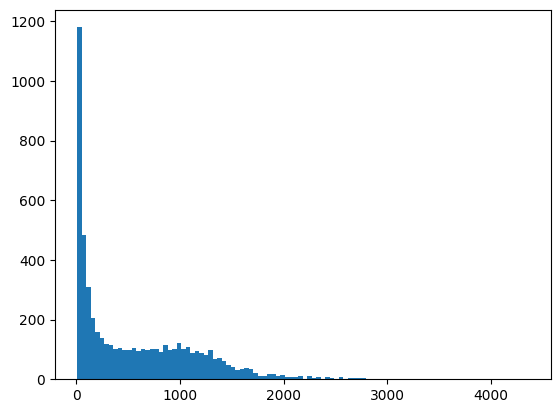

In [ ]:
plt.hist(areas, bins=100)
plt.show()